# 02 — Emotion Classifier: EDA + Post-Training Analysis

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

SPLITS    = ROOT / 'data' / 'splits'
MODEL_DIR = ROOT / 'models' / 'emotion_classifier'

plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
print('Ready')

Ready


## 1. Data Analysis

In [4]:
from config import EMOTION_SPLIT_PATH

train = pd.read_csv('../data/processed/emotion_train.csv')
val   = pd.read_csv('../data/processed/emotion_val.csv')
test  = pd.read_csv('../data/processed/emotion_test.csv')

print(f'Splits:  train={len(train):,}  val={len(val):,}  test={len(test):,}')
train.head(4)

Splits:  train=31,716  val=1,950  test=1,951


,text,label
0,i just had a shocking realization,5
1,i feel a bit calm now,1
2,i just saw a shooting star in the sky,5
3,i think the whimsical pop art feel of the plac...,1


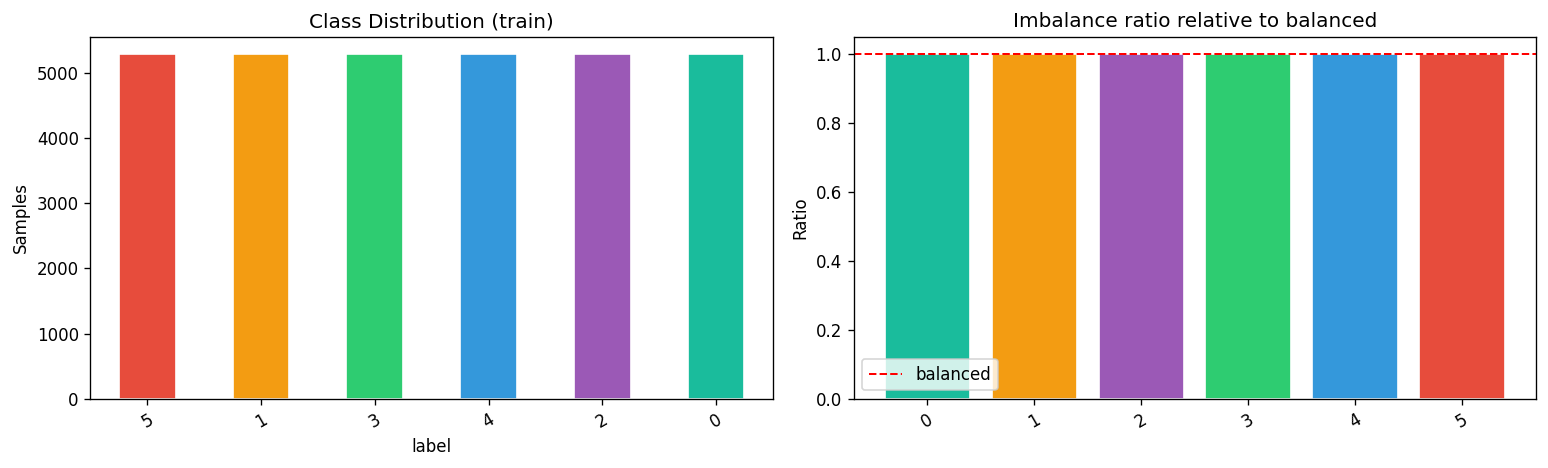

Imbalance: max=5286 (5) vs min=5286 (5)  ratio=1.0x

Counts + %:
  5           5286  (16.7%)
  1           5286  (16.7%)
  3           5286  (16.7%)
  4           5286  (16.7%)
  2           5286  (16.7%)
  0           5286  (16.7%)


In [6]:
# Class distribution with imbalance indicator
counts = train['label'].value_counts()
colors = ['#e74c3c','#f39c12','#2ecc71','#3498db','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts.plot(kind='bar', ax=axes[0], color=colors[:len(counts)], edgecolor='white')
axes[0].set_title('Class Distribution (train)', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Samples')

# Imbalance — show ratio vs balanced baseline
balanced = len(train) / len(counts)
axes[1].bar(counts.index, counts.values / balanced, color=colors[:len(counts)], edgecolor='white')
axes[1].axhline(1, color='red', linestyle='--', linewidth=1.2, label='balanced')
axes[1].set_title('Imbalance ratio relative to balanced', fontsize=12)
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylabel('Ratio')
axes[1].legend()

plt.tight_layout(); plt.show()

vc = counts
print(f'Imbalance: max={vc.max()} ({vc.idxmax()}) vs min={vc.min()} ({vc.idxmin()})  ratio={vc.max()/vc.min():.1f}x')
print('\nCounts + %:')
for emo, cnt in counts.items():
    print(f'  {emo:<10} {cnt:>5}  ({cnt/len(train)*100:.1f}%)')

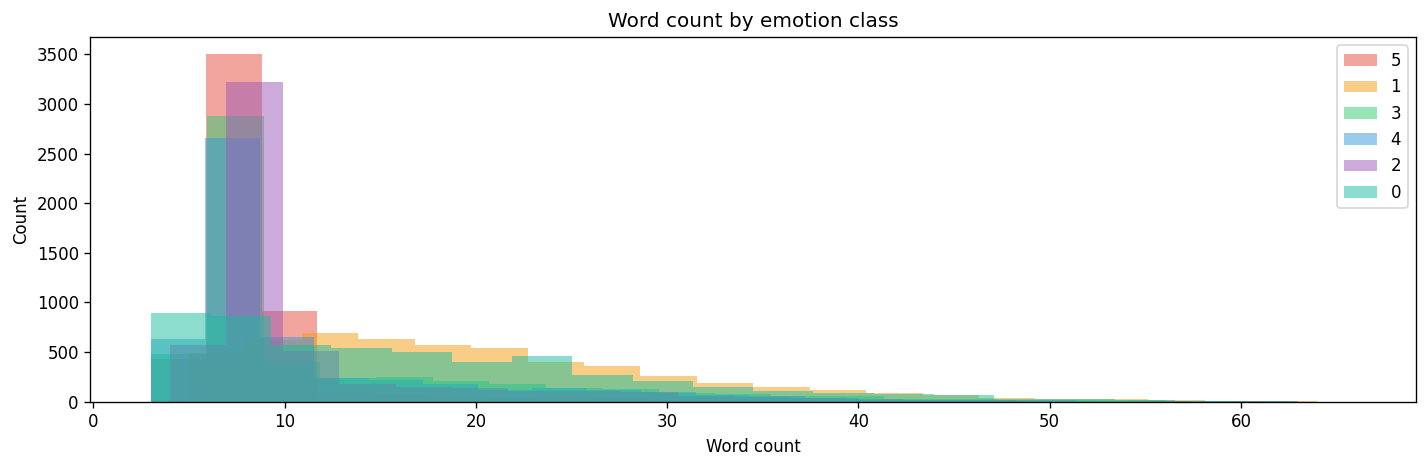

Stats per emotion:
        count  mean   std  min   25%   50%   75%   max
label                                                 
0      5286.0  16.9  11.1  3.0   8.0  14.0  23.0  66.0
1      5286.0  19.7  10.7  5.0  12.0  18.0  26.0  64.0
2      5286.0  10.9   7.7  4.0   7.0   8.0  10.0  63.0
3      5286.0  11.8   9.6  3.0   6.0   7.0  14.0  62.0
4      5286.0  11.1   8.7  3.0   6.0   7.0  12.0  60.0
5      5286.0   8.5   5.4  3.0   6.0   7.0   9.0  61.0


In [7]:
# Text length distribution per emotion
train['wc'] = train['text'].str.split().apply(len)

fig, ax = plt.subplots(figsize=(12, 4))
for emo, color in zip(train['label'].unique(), colors):
    subset = train[train['label'] == emo]['wc']
    ax.hist(subset, bins=20, alpha=0.5, label=emo, color=color)
ax.set_title('Word count by emotion class', fontsize=12)
ax.set_xlabel('Word count'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout(); plt.show()

print('Stats per emotion:')
print(train.groupby('label')['wc'].describe().round(1).to_string())

In [9]:
# Sample texts from each class
print('3 samples per emotion class:')
print('=' * 70)
for emo in ['anger','fear','joy','love','sadness','surprise']:
    samples = train[train['label'] == emo]['text'].head(3)
    print(f'\n  [{emo.upper()}]')
    for s in samples:
        print(f'    • {s}')

3 samples per emotion class:

  [ANGER]

  [FEAR]

  [JOY]

  [LOVE]

  [SADNESS]

  [SURPRISE]


## 3. Post-Training: Load Results

Training history:
 epoch  train_loss  val_loss  val_acc  val_f1  elapsed_s
     1      0.0741    0.1917    0.939  0.9183       61.5
     2      0.0753    0.1917    0.939  0.9183       60.3
     3      0.0736    0.1917    0.939  0.9183       60.5
     4      0.0758    0.1917    0.939  0.9183       60.4
     5      0.0737    0.1917    0.939  0.9183       60.5
     6      0.0759    0.1917    0.939  0.9183       60.4


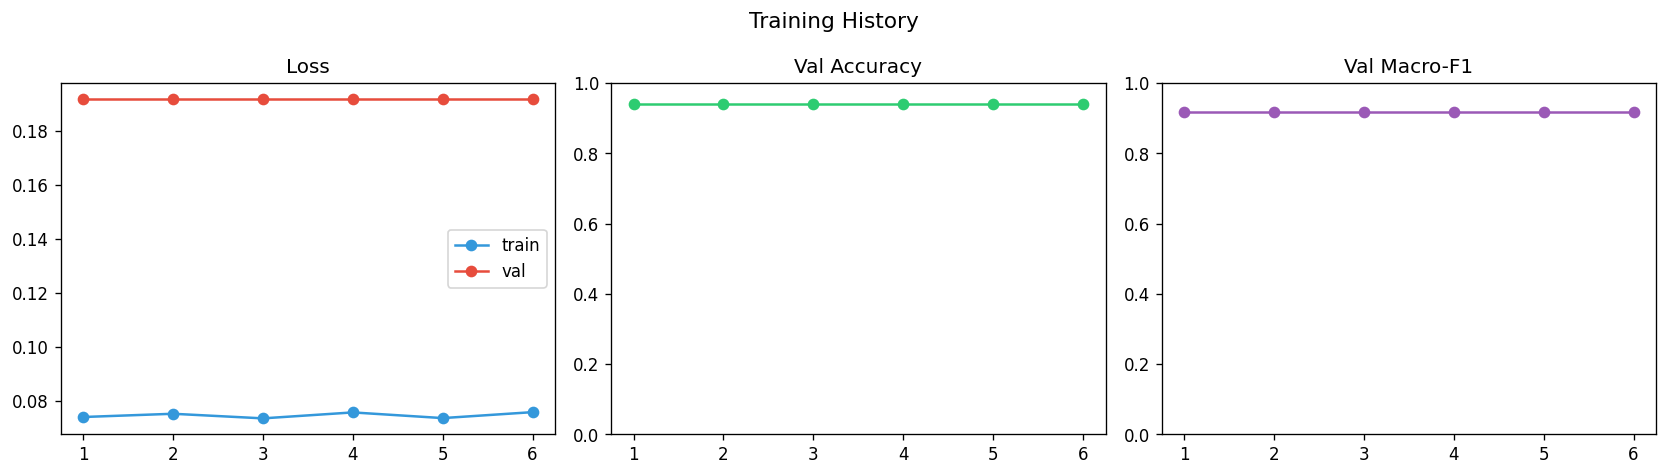

In [12]:
import json

log_path = MODEL_DIR / 'training_log.txt'
cfg_path = MODEL_DIR / 'train_config.json'

if log_path.exists():
    history = pd.read_csv(log_path, comment='#')
    print('Training history:')
    print(history.to_string(index=False))
    
    if len(history) > 1:  # only plot if we have real training data
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        axes[0].plot(history['epoch'], history['train_loss'], 'o-', label='train', color='#3498db')
        axes[0].plot(history['epoch'], history['val_loss'],   'o-', label='val',   color='#e74c3c')
        axes[0].set_title('Loss'); axes[0].legend()
        axes[1].plot(history['epoch'], history['val_acc'],  'o-', color='#2ecc71')
        axes[1].set_title('Val Accuracy'); axes[1].set_ylim(0,1)
        axes[2].plot(history['epoch'], history['val_f1'],   'o-', color='#9b59b6')
        axes[2].set_title('Val Macro-F1'); axes[2].set_ylim(0,1)
        plt.suptitle('Training History', fontsize=13)
        plt.tight_layout(); plt.show()
else:
    print('No training log yet — run scripts/02_train_emotion_classifier.py or Kaggle notebook first.')

if cfg_path.exists():
    with open(cfg_path) as f: cfg = json.load(f)
    print(f"\nConfig: best_val_f1={cfg.get('best_val_f1')}  "
          f"test_acc={cfg.get('test_accuracy')}  test_f1={cfg.get('test_macro_f1')}")

## 4. Wrapper Demo

In [14]:
import time
from src.emotion_classifier import EmotionClassifier

clf = EmotionClassifier()
print(clf)

examples = [
    "I feel absolutely hopeless and want to give up everything.",
    "This is the best day of my life, I am so happy!",
    "I am furious about what just happened, this is unacceptable.",
    "I am so scared and nervous, I cannot stop shaking.",
    "I love you so much, you mean everything to me.",
    "Wow, I never expected that, completely shocked!",
    "I've been feeling really down lately and can't find joy in anything.",
    "I'm so anxious about my appointment tomorrow, can't eat or sleep.",
]

print(f'\n{"Text":<52}  {"Emotion":<10}  {"Conf":>6}  {"ms":>5}')
print('-' * 78)
for text in examples:
    t0  = time.time()
    res = clf.classify(text)
    ms  = (time.time() - t0) * 1000
    print(f"  {text[:50]:<50}  {res['emotion']:<10}  {res['confidence']:>6.3f}  {ms:>4.0f}ms")


Text                                                  Emotion       Conf     ms
------------------------------------------------------------------------------
📖 Reading configuration from D:\Desktop\ITI Notes\NLP\Mental Health Chatbot\mental_health_chatbot\models\emotion_classifier\emotion_config.yaml...
📥 Initializing Tokenizer (bert-base-uncased)...
🧠 Building BiLSTM and injecting state dict...
📦 Training checkpoint wrapper detected. Extracting 'model_state' weights...
✅ BiLSTM Emotion Classifier state weights successfully mapped and loaded!
  I feel absolutely hopeless and want to give up eve  sadness      1.000  1896ms
  This is the best day of my life, I am so happy!     joy          0.586    11ms
  I am furious about what just happened, this is una  surprise     0.608     9ms
  I am so scared and nervous, I cannot stop shaking.  fear         0.869     7ms
  I love you so much, you mean everything to me.      love         1.000     6ms
  Wow, I never expected that, completely sho

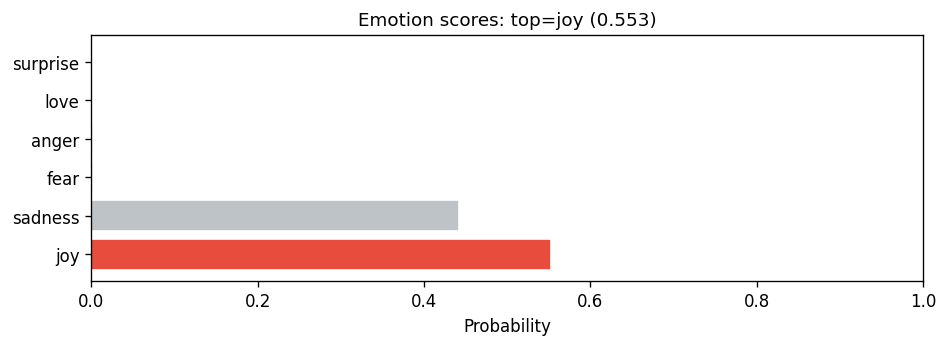

In [15]:
# Confidence bar chart for one example
res = clf.classify("I've been feeling really down lately and can't find joy in anything.")
scores = res['all_scores']

fig, ax = plt.subplots(figsize=(8, 3))
cols = ['#e74c3c' if e == res['emotion'] else '#bdc3c7' for e in scores.keys()]
ax.barh(list(scores.keys()), list(scores.values()), color=cols, edgecolor='white')
ax.set_xlim(0, 1)
ax.set_title(f"Emotion scores: top={res['emotion']} ({res['confidence']:.3f})", fontsize=11)
ax.set_xlabel('Probability')
plt.tight_layout(); plt.show()